In [1]:
import pandas as pd
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats import multitest
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import compress

In [2]:
def itertool_stats(dict, method, key = None, ns = None):
    for subset in itertools.combinations(dict.keys(), 2):
        if method == 'chi2_contingency':
            stat, p, dof, expected  = stats.chi2_contingency([[dict[subset[0]], ns[subset[0]] - dict[subset[0]]],
                                                [dict[subset[1]], ns[subset[1]] - dict[subset[1]]]])
            print(subset, p)
        elif method == 'fisher':
            oddsratio, p  = stats.fisher_exact([dict[subset[0]],
                                        dict[subset[1]]])
            print(subset, p)
        elif method == 'ttest':
            stat, p = stats.ttest_ind(dict[subset[0]],
                                       dict[subset[1]],
                                       equal_var = False)
            print(subset, p)

In [14]:
def cell_group_import(channel):
    dfs = []
    all_files = glob.glob(os.path.join('data/' + '*' + channel + '.feather'))

    for file in all_files:
        df = pd.read_feather(file)
        id = df['Image'][0][:11]
        if id == '2021_04_10_':
            id = 'BRAC5112.5g'
        df = df.groupby(['BrainRegion', 'Class']).size().reset_index(name='Num_cells')
        #df = df.groupby(['BrainRegion']).size().reset_index(name='Num_cells')
        df['id'] = id
        df['channel'] = channel
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index = True)
    
    return data

def area_import():
    dfs = []
    all_files = glob.glob(os.path.join('Allen_area',  '*.csv'))
    for file in all_files:
        df = pd.read_csv(file)
        df['id'] = file[11:22]
        dfs.append(df)
    data = pd.concat(dfs, ignore_index = True)
    data.rename(columns={'Name': 'BrainRegion'}, inplace=True)
    return data

In [15]:
sns.set_context("notebook", rc={"font.family": 'sans-serif',
                                'font.sans-serif': 'DejaVu Sans'})

import cfos, DAPI and state data

In [16]:
areas = pd.read_csv('selected_area.csv', encoding='cp1252')['area'].tolist()
abbr = pd.read_csv('selected_area.csv', encoding='cp1252')['abbr'].tolist()

In [24]:
state = pd.read_csv('state.csv', encoding='cp1252')
dfs = []
merged_df = cell_group_import('cfos')
area = area_import()

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_17035/845270567.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(['BrainRegion', 'Class']).size().reset_index(name='Num_cells')
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_17035/845270567.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(['BrainRegion', 'Class']).size().reset_index(name='Num_cells')
/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_17035/845270567.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pa

In [25]:
merged_df.to_csv('cfos.csv')

In [26]:
merged_df = merged_df.merge(area, how = 'left', on=['id', 'BrainRegion'])
merged_df['cfos/area'] = merged_df[merged_df['Class'] == 'positive']['Num_cells'] / merged_df['total_area'] *1000000
#merged_df['cfos/area'] = merged_df['Num_cells'] / merged_df['total_area'] *1000000
merged_df = merged_df.merge(state, how = 'left', on = 'id')

In [27]:
print(merged_df[merged_df['state_after'] == 'Agg+']['id'].unique())
print(merged_df[merged_df['state_after'] == 'Agg-']['id'].unique())

['BRAC5872.1f' 'BRAC5872.1g' 'BRAC5603.3e' 'BRAC5487.3j' 'BRAC5872.1d'
 'BRAC5872.1c']
['BRAC5487.3i' 'BRAC5112.5g' 'BRAC5487.3k' 'BRAC5481.2e' 'BRAC5603.3f']


In [28]:
p = []
reg = []
for region in areas:
    agg_plus = merged_df[(merged_df['BrainRegion'] == region) & 
                         (merged_df['Class'] == 'positive') & 
                         (merged_df['state_after'] == 'Agg+')]['cfos/area'].fillna(0).tolist()
    agg_minus = merged_df[(merged_df['BrainRegion'] == region) &  
                          (merged_df['Class'] == 'positive') & 
                          (merged_df['state_after'] == 'Agg-')]['cfos/area'].fillna(0).tolist()
    
    stats1, p1 = stats.mannwhitneyu(agg_plus,
                                   agg_minus)
    p.append(p1)
    reg.append(region)
    #print(p1, agg_plus, agg_minus, region)
    if p1<0.05:
        print(p1, region)
        
p_corrected = multitest.multipletests(p, method = 'fdr_bh')
positive_ls = list(compress(reg, p_corrected[0]))
print(positive_ls)
positive_p = list(compress(p, p_corrected[0]))
positive_ls.extend(['Paraventricular nucleus of the thalamus',
                   'Cortical amygdalar area, posterior part, lateral zone',
                   'Cortical amygdalar area, posterior part, medial zone',
                  'Medial amygdalar nucleus', 'Ventromedial hypothalamic nucleus'])

0.008658008658008658 Anteroventral periventricular nucleus
0.004329004329004329 Anteroventral preoptic nucleus
0.030303030303030304 Lateral hypothalamic area
0.004329004329004329 Lateral preoptic area
0.004329004329004329 Medial preoptic area
0.017316017316017316 Median preoptic nucleus
0.004329004329004329 Parastrial nucleus
0.004329004329004329 Tuberal nucleus
0.017316017316017316 Ventromedial hypothalamic nucleus
['Anteroventral preoptic nucleus', 'Lateral preoptic area', 'Medial preoptic area', 'Parastrial nucleus', 'Tuberal nucleus']


In [29]:
print(merged_df[ (merged_df['Class'] == 'positive') &
                (merged_df['BrainRegion'].isin(positive_ls))]['BrainRegion'].unique())
#abbr = ['AVPV','COApl', 'COApm', 'LPOA', 'MEA', 
#        'MPOA', 'PS', 'PVT','TU', 'VMH']

['Anteroventral preoptic nucleus'
 'Cortical amygdalar area, posterior part, lateral zone'
 'Cortical amygdalar area, posterior part, medial zone'
 'Lateral preoptic area' 'Medial amygdalar nucleus' 'Medial preoptic area'
 'Parastrial nucleus' 'Paraventricular nucleus of the thalamus'
 'Tuberal nucleus' 'Ventromedial hypothalamic nucleus']


In [31]:
# reorder BrainRegion column based on list area
categ = merged_df[(merged_df['BrainRegion'].isin(areas)) & 
                         (merged_df['Class'] == 'positive')]
categ.BrainRegion = categ.BrainRegion.astype("category")
categ.BrainRegion.cat.set_categories(areas)
categ = categ.sort_values(['BrainRegion'])
categ['BrainRegion'] = categ['BrainRegion'].cat.codes

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_17035/3212706446.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  categ.BrainRegion = categ.BrainRegion.astype("category")


In [32]:
categ[categ.BrainRegion == 27]

,BrainRegion,Class,Num_cells,id,channel,Unnamed: 0,total_area,cfos/area,state_before,retrieval_before_latency,...,state_after,state_after_latency,parental_state_after,retrieval_after_latency,state_after_comment,1h_food_consumption_after,target,exp_time,prev_exp,exp_date
8141,27,positive,1386,BRAC5872.1c,cfos,208.0,4493584.9,308.439705,Parental-,NaN,...,Agg+,NaN,NaN,NaN,NaN,0.9,C-fos,1.0,NaN,26/05/21
7267,27,positive,1915,BRAC5872.1d,cfos,210.0,9358169.6,204.634034,Parental-,NaN,...,Agg+,NaN,NaN,NaN,NaN,0.9,C-fos,1.0,NaN,26/05/21
6389,27,positive,1596,BRAC5487.3j,cfos,223.0,6737914.3,236.868551,Parental+,NaN,...,Agg+,NaN,NaN,NaN,NaN,0.7,C-fos,1.0,NaN,12/05/21
5475,27,positive,1970,BRAC5481.2e,cfos,223.0,4924872.8,400.010331,Parental+,NaN,...,Agg-,NaN,Parental+,NaN,retrieve both pups,0.5,C-fos,1.0,NaN,29/04/21
9031,27,positive,2247,BRAC5603.3f,cfos,215.0,4502153.3,499.094511,Parental+,NaN,...,Agg-,NaN,Parental+,NaN,build a nest around the pups,0.4,C-fos,1.0,NaN,30/04/21
4567,27,positive,2212,BRAC5487.3k,cfos,207.0,4682829.9,472.363944,Parental+,NaN,...,Agg-,NaN,Parental+,NaN,build a nest around the pups,0.3,C-fos,1.0,NaN,12/05/21
1149,27,positive,1208,BRAC5872.1g,cfos,176.0,3771876.5,320.264993,Parental-,NaN,...,Agg+,NaN,NaN,NaN,NaN,0.6,C-fos,1.0,NaN,26/05/21
3701,27,positive,2975,BRAC5112.5g,cfos,198.0,5894783.0,504.683548,Parental-,NaN,...,Agg-,NaN,Parental+,NaN,retrieve both pups,NaN,NaN,NaN,NaN,NaN
1979,27,positive,1931,BRAC5487.3i,cfos,218.0,4670024.6,413.488186,Parental+,NaN,...,Agg-,NaN,Parental+,NaN,retrieve one pup,0.5,C-fos,1.0,NaN,12/05/21
315,27,positive,1554,BRAC5872.1f,cfos,208.0,4616203.1,336.640301,Parental-,NaN,...,Agg+,NaN,NaN,NaN,pup was consumed – which may compromise the th...,0.4,C-fos,1.0,NaN,26/05/21


/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

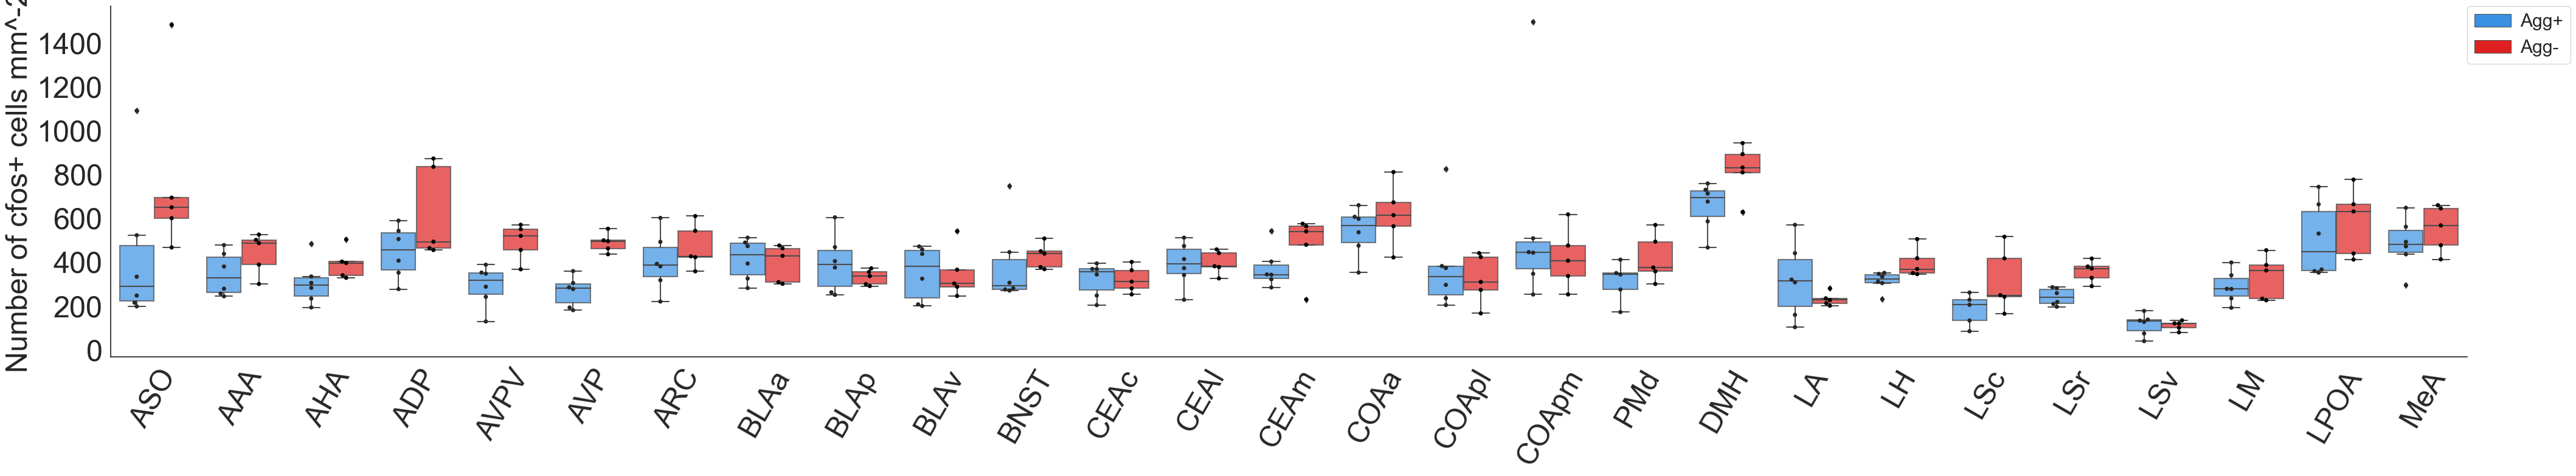

In [33]:
plt.rc('font', family='serif')
sns.set(rc={'figure.figsize':(50,7.5)})
sns.set(font_scale=1.5)
sns.set_style("white")
fig,ax = plt.subplots()
sns.swarmplot(x = 'BrainRegion', 
              y = 'cfos/area', 
              hue = 'state_after', 
              data = categ[:27*11-1] ,
              dodge = True,
              color = 'black')


g = sns.boxplot(x = 'BrainRegion', 
            y = 'cfos/area', 
            hue = 'state_after', 
            data = categ[:27*11-1], 
            dodge = True, 
            palette = ['dodgerblue', 'red'],
            boxprops=dict(alpha=.7))

handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(handles[2:4], labels[2:4],
                bbox_to_anchor=(1, 1), 
                loc=2, borderaxespad=0,
                fontsize='large',
                handletextpad = 0.5)
plt.xlabel(None)
plt.ylabel('Number of cfos+ cells mm^-2', fontsize = 35)
g.set_xticklabels(abbr[:27],fontsize = 35)
plt.yticks(fontsize = 35)
plt.xticks(rotation=60)
sns.despine()
plt.savefig('cfos_1.jpg', dpi=600, bbox_inches='tight')

/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/caom/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) 

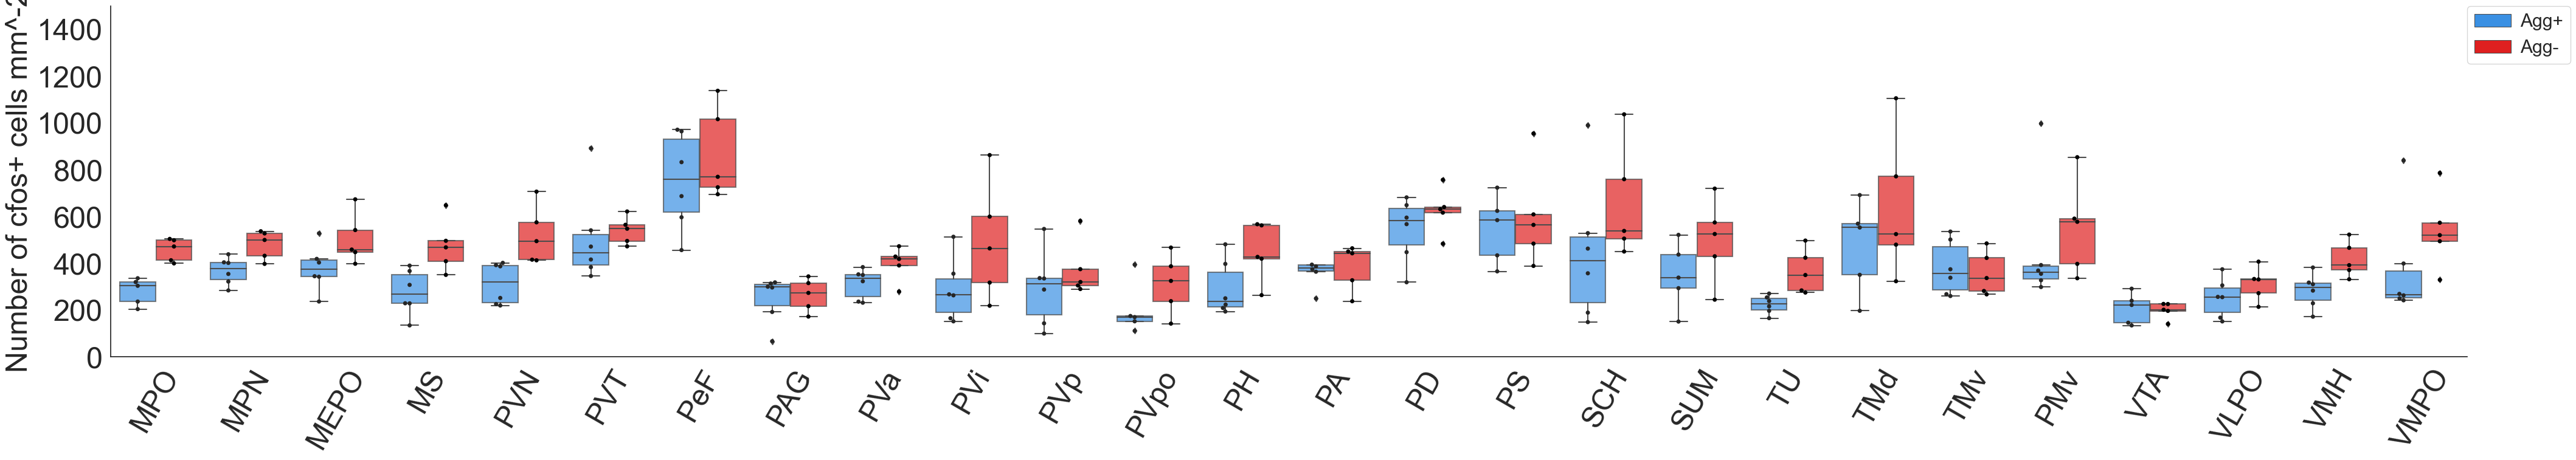

In [34]:
plt.rc('font', family='serif')
sns.set(rc={'figure.figsize':(50,7.5)})
sns.set(font_scale=1.5)
sns.set_style("white")
fig,ax = plt.subplots()
sns.swarmplot(x = 'BrainRegion', 
              y = 'cfos/area', 
              hue = 'state_after', 
              data = categ[27*11:] ,
              dodge = True,
              color = 'black')

g = sns.boxplot(x = 'BrainRegion', 
            y = 'cfos/area', 
            hue = 'state_after', 
            data = categ[27*11:], 
            dodge = True, 
            palette = ['dodgerblue', 'red'],
            boxprops=dict(alpha=.7))

handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(handles[2:4], labels[2:4],
                bbox_to_anchor=(1, 1), 
                loc=2, borderaxespad=0,
                fontsize='large',
                handletextpad = 0.5)
plt.xlabel(None)
plt.ylabel('Number of cfos+ cells mm^-2', fontsize = 35)
plt.yticks(fontsize = 35)
g.set_xticklabels(abbr[27:], fontsize = 35)
plt.xticks(rotation=60)
ax = plt.gca()
ax.set_ylim([0, 1500])
sns.despine()
plt.savefig('cfos_2.jpg', dpi=600,bbox_inches='tight')